In [18]:
from common_helper_functions import *

In [19]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
go_dna = np.load( path + 'go_dna_dataset.npz')

In [20]:
investigate_dataset(go_dna)

['X', 'y', 'genes']

Array shapes:


X shape: (3697, 12288, 6)
y shape: (3697, 10)
genes shape: (3697,)

First few y values: [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]

X dimensions: 3

X dimensions: 3
X first sample shape: (12288, 6)
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 1. 0. 0. 0.]
X first sample, first feature vector: [0. 1. 0. 0. 0.]


In [21]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(go_dna['X'], go_dna['genes'], n_components=2048)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (3697, 2048)


In [22]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 88.04%


In [23]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, go_dna['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484381,19.997217,-3.263620,6.096070,2.878503,2.100385,4.996945,3.763488,-2.090878,4.035175,...,-1.263815,0.463491,0.708359,0.743112,0.444223,0.179213,0.990975,-0.997602,0.474628,0.954084
FGR,-9.459971,17.357420,-2.683357,-1.475254,5.934594,0.881204,4.911150,-0.139770,5.210960,2.031858,...,0.366252,0.132188,1.401473,-0.082755,-0.590346,0.205131,0.821058,1.098178,-1.605264,-0.297455
CFH,8.703356,23.714632,-4.039974,9.490250,-7.428704,3.553900,-0.899138,-2.732009,-10.455998,5.410104,...,-0.708006,0.325740,-0.516150,0.584850,0.426662,-0.411393,-0.979813,0.217770,-0.030361,0.768518
NFYA,15.312556,-8.760286,-8.302457,0.726779,-4.642266,-10.267315,-7.944747,3.541034,4.940904,-1.913305,...,-0.218195,0.159079,-0.291938,0.180316,0.214152,-0.829488,-0.300447,-0.095627,-0.006727,0.051416
CFTR,20.702242,-18.581911,-19.757959,0.525863,8.217184,4.777837,-9.161017,-4.210721,-1.545652,9.986770,...,-0.241593,-0.589167,-0.238693,-0.262579,0.248779,-0.348628,0.734415,-0.216202,0.443011,-0.235948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAF11L7,-15.407385,5.946139,-1.468846,-10.506921,5.136970,-4.193428,-4.807790,-5.273279,-5.704342,-1.174108,...,-0.251507,0.191714,0.392215,0.150680,0.034959,0.058751,0.194739,0.216798,0.012668,-0.114106
CPHXL2,-14.601638,-6.739897,-9.937522,-7.373076,-5.923116,-6.634275,-1.230262,-2.815694,-2.358846,-0.869916,...,-0.523746,0.053959,-0.448348,0.549666,-0.241097,-0.397320,-0.884065,0.587024,-0.390295,-0.474926
C8orf44-SGK3,-2.840687,14.210365,-2.690796,6.343112,0.053496,2.255734,3.574312,5.975232,-1.967692,2.915342,...,0.356972,-1.486473,-0.403074,-1.689610,0.886855,0.736955,-0.794944,-0.691645,1.199480,0.803804


In [24]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [25]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484381,19.997217,-3.263620,6.096070,2.878503,2.100385,4.996945,3.763488,-2.090878,4.035175,...,-1.263815,0.463491,0.708359,0.743112,0.444223,0.179213,0.990975,-0.997602,0.474628,0.954084
FGR,-9.459971,17.357420,-2.683357,-1.475254,5.934594,0.881204,4.911150,-0.139770,5.210960,2.031858,...,0.366252,0.132188,1.401473,-0.082755,-0.590346,0.205131,0.821058,1.098178,-1.605264,-0.297455
CFH,8.703356,23.714632,-4.039974,9.490250,-7.428704,3.553900,-0.899138,-2.732009,-10.455998,5.410104,...,-0.708006,0.325740,-0.516150,0.584850,0.426662,-0.411393,-0.979813,0.217770,-0.030361,0.768518
NFYA,15.312556,-8.760286,-8.302457,0.726779,-4.642266,-10.267315,-7.944747,3.541034,4.940904,-1.913305,...,-0.218195,0.159079,-0.291938,0.180316,0.214152,-0.829488,-0.300447,-0.095627,-0.006727,0.051416
CFTR,20.702242,-18.581911,-19.757959,0.525863,8.217184,4.777837,-9.161017,-4.210721,-1.545652,9.986770,...,-0.241593,-0.589167,-0.238693,-0.262579,0.248779,-0.348628,0.734415,-0.216202,0.443011,-0.235948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAF11L7,-15.407385,5.946139,-1.468846,-10.506921,5.136970,-4.193428,-4.807790,-5.273279,-5.704342,-1.174108,...,-0.251507,0.191714,0.392215,0.150680,0.034959,0.058751,0.194739,0.216798,0.012668,-0.114106
CPHXL2,-14.601638,-6.739897,-9.937522,-7.373076,-5.923116,-6.634275,-1.230262,-2.815694,-2.358846,-0.869916,...,-0.523746,0.053959,-0.448348,0.549666,-0.241097,-0.397320,-0.884065,0.587024,-0.390295,-0.474926
C8orf44-SGK3,-2.840687,14.210365,-2.690796,6.343112,0.053496,2.255734,3.574312,5.975232,-1.967692,2.915342,...,0.356972,-1.486473,-0.403074,-1.689610,0.886855,0.736955,-0.794944,-0.691645,1.199480,0.803804


In [26]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484381,19.997217,-3.263620,6.096070,2.878503,2.100385,4.996945,3.763488,-2.090878,4.035175,...,0.444223,0.179213,0.990975,-0.997602,0.474628,0.954084,False,False,False,False
FGR,-9.459971,17.357420,-2.683357,-1.475254,5.934594,0.881204,4.911150,-0.139770,5.210960,2.031858,...,-0.590346,0.205131,0.821058,1.098178,-1.605264,-0.297455,False,False,False,False
CFH,8.703356,23.714632,-4.039974,9.490250,-7.428704,3.553900,-0.899138,-2.732009,-10.455998,5.410104,...,0.426662,-0.411393,-0.979813,0.217770,-0.030361,0.768518,False,False,False,False
NFYA,15.312556,-8.760286,-8.302457,0.726779,-4.642266,-10.267315,-7.944747,3.541034,4.940904,-1.913305,...,0.214152,-0.829488,-0.300447,-0.095627,-0.006727,0.051416,False,False,False,False
CFTR,20.702242,-18.581911,-19.757959,0.525863,8.217184,4.777837,-9.161017,-4.210721,-1.545652,9.986770,...,0.248779,-0.348628,0.734415,-0.216202,0.443011,-0.235948,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL3,-15.490881,-0.406331,-2.594788,-9.861942,-1.599759,-4.762577,-4.898837,-4.700237,-5.546359,-3.239719,...,-0.138141,0.365106,-0.633906,0.571108,0.683560,0.486894,False,False,False,False
SSTR3,4.326692,-5.663867,12.208844,9.123982,1.093340,0.461667,1.553391,-4.534107,-0.840339,-7.032008,...,-0.744222,-0.370852,0.651162,-0.716250,0.582637,-0.085506,False,False,False,False
MYO19,5.753089,-14.638472,-17.008093,9.437114,5.492837,7.279717,1.104665,-5.904333,-3.853745,0.653545,...,-1.308287,0.618872,-0.137011,1.598929,0.096342,1.659568,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [27]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    2956
True      313
Name: count, dtype: int64

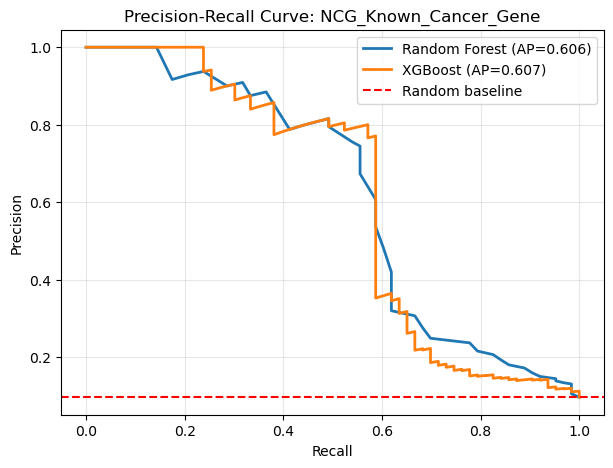

In [28]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [29]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    2899
True      370
Name: count, dtype: int64

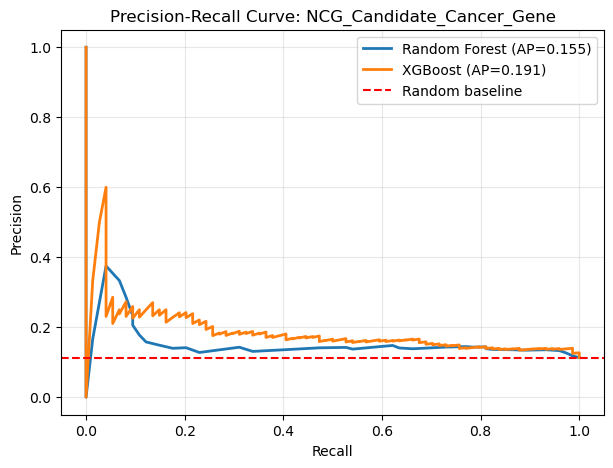

In [30]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [31]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    3016
True      253
Name: count, dtype: int64

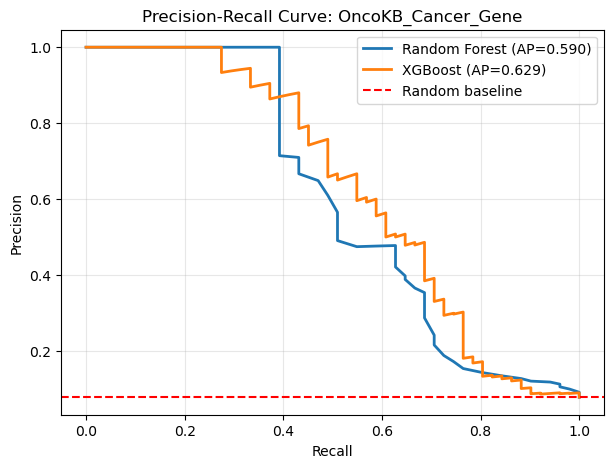

In [32]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [33]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    3134
True      135
Name: count, dtype: int64

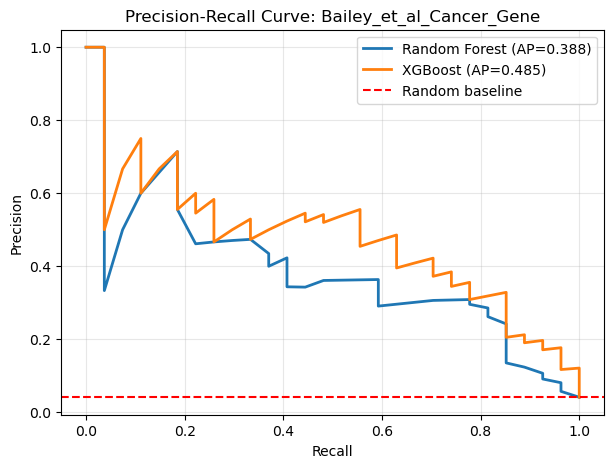

In [34]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')